# Cuaderno 03 · Explicaciones globales y contrafactuales

### Serie *Inferencia Causal + IA Explicativa* · Capítulo 3 de 10

> Cuaderno reproducible asociado al artículo divulgativo **«De la correlación a la causa: inteligencia artificial explicable e inferencia causal»**. Datos abiertos; ejecución completa.

---

El cuaderno 02 explicó predicciones **individuales**. Este aborda dos preguntas complementarias: *¿cómo se comporta el modelo en su conjunto?* —explicaciones **globales**— y *¿qué cambio mínimo en un caso alteraría su decisión?* —explicaciones **contrafactuales**—. Se desarrollan cinco métodos (importancia por permutación, PDP, ICE, ALE, modelo sustituto y contrafactuales con DiCE), cada uno con su fundamento, un ejemplo sobre el modelo de *scoring* crediticio y su comparación crítica. Todos comparten un límite: describen el modelo sobre la distribución observada, sin acceder al nivel causal.

## Contenido

| Sección | Método | Fundamento |
|---|---|---|
| 0 | Modelo de referencia (Pipeline one-hot + XGBoost) | sobre variables originales |
| 1 | Importancia por permutación | caída de desempeño al permutar |
| 2 | PDP e ICE | efecto marginal promedio e individual |
| 3 | ALE | efectos locales acumulados (bajo correlación) |
| 4 | Modelo sustituto global | árbol interpretable que imita la caja negra |
| 5 | Contrafactuales (DiCE) | cambio mínimo que voltea la decisión |

**Salidas gráficas:** importancia por permutación · PDP+ICE · ALE vs PDP · árbol sustituto · cambios contrafactuales.

**Objetivos.** (i) Definir y calcular cada método sobre un modelo real; (ii) mostrar por qué PDP se sesga bajo correlación y cómo ALE lo corrige; (iii) cuantificar la fidelidad de un modelo sustituto; (iv) generar recursos contrafactuales y precisar su carácter no causal.

> **Definición 5.1 (explicación contrafactual / recurso).** Dado $x$ con una predicción indeseada y una clase objetivo $y^{*}$, un *contrafactual* es
> $$ x_{cf}=\arg\min_{x'}\ \mathrm{yloss}\big(f(x'),y^{*}\big)+\lambda\,d(x,x'), $$
> donde $\mathrm{yloss}$ exige alcanzar $y^{*}$ y $d$ penaliza cambios grandes o numerosos (proximidad y dispersión). **DiCE** añade un término de **diversidad** para ofrecer varias alternativas. Es una explicación a nivel de **un caso** (recurso accionable).
>
> **Observación 5.1.** El contrafactual es del **modelo**, no del mundo: minimiza el cambio en las *entradas* para mover la *predicción*, sin garantizar plausibilidad causal. Un recurso causalmente válido debe respetar el mecanismo generador (operador $do$) — el puente al cuaderno 04 y a la Sección 2 del curso.

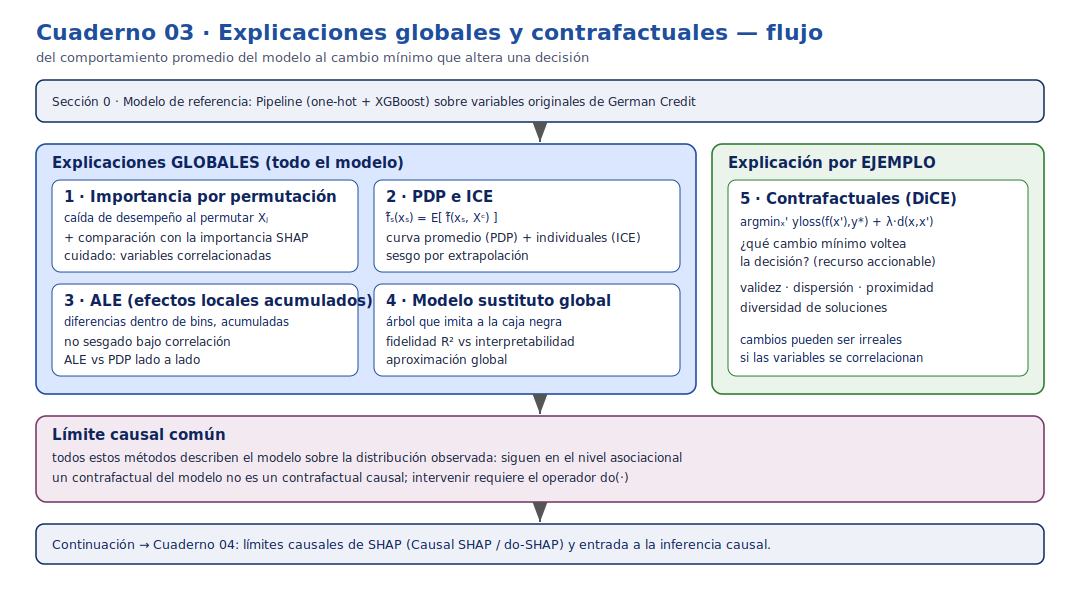

In [1]:
# Diagrama de flujo del cuaderno (se incrusta en la salida)
from pathlib import Path
from IPython.display import SVG, display
_svg = Path('../img/03_flujo.svg')
if not _svg.exists():
    _svg = Path('img/03_flujo.svg')
display(SVG(filename=str(_svg)))

In [2]:
# Sección 0 · Modelo de referencia sobre las variables ORIGINALES de German Credit
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(ROOT))
from src.data import load_german_credit

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE); np.random.seed(RANDOM_STATE)
plt.rcParams.update({"figure.figsize": (7, 4.2), "axes.grid": True, "axes.axisbelow": True})

df = load_german_credit()
y = df["riesgo_bueno"]
num = ["duracion_meses", "monto_credito", "tasa_cuota_pct", "residencia_desde",
       "edad", "n_creditos_banco", "n_dependientes"]
Xraw = df.drop(columns=["riesgo", "riesgo_bueno", "estado_personal_sexo", "sexo"]).copy()
Xraw[num] = Xraw[num].astype(float)          # PDP/ICE requieren flotantes
cat = [c for c in Xraw.columns if c not in num]

pre = ColumnTransformer(
    [("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)],
    remainder="passthrough", verbose_feature_names_out=False)
model = Pipeline([("pre", pre),
                  ("clf", XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                                        subsample=0.9, eval_metric="logloss",
                                        random_state=RANDOM_STATE))])
X_tr, X_te, y_tr, y_te = train_test_split(Xraw, y, test_size=0.30, stratify=y,
                                          random_state=RANDOM_STATE)
model.fit(X_tr, y_tr)
print(f"AUC (Pipeline XGBoost): {roc_auc_score(y_te, model.predict_proba(X_te)[:, 1]):.3f}")
print(f"{Xraw.shape[1]} variables originales · {len(num)} numéricas, {len(cat)} categóricas")

AUC (Pipeline XGBoost): 0.763
19 variables originales · 7 numéricas, 12 categóricas


## Sección 1 · Importancia por permutación

Mide cuánto se degrada el desempeño del modelo al **romper** la relación entre una variable y el objetivo, permutando aleatoriamente sus valores. Para una métrica $L$ (aquí el AUC) y la variable $j$:

$$ I_j \;=\; L\big(y, f(X)\big) \;-\; \mathbb E_{\pi}\big[L\big(y, f(X^{(\pi, j)})\big)\big], $$

donde $X^{(\pi,j)}$ es $X$ con la columna $j$ permutada. Un $I_j$ grande indica fuerte dependencia del modelo respecto a esa variable. Es **global** y **agnóstica** al modelo. Se promedia sobre varias permutaciones para estimar su desviación.

> **Definición 1.1 (importancia por permutación).** Para una métrica de desempeño $L$ y la variable $j$, la *importancia por permutación* es
> $$ I_j=L\big(y,f(X)\big)-\mathbb E_\pi\big[L\big(y,f(X^{(\pi,j)})\big)\big], $$
> donde $X^{(\pi,j)}$ es $X$ con la columna $j$ permutada al azar (destruyendo su asociación con el objetivo). Es **global** y **agnóstica** al modelo.

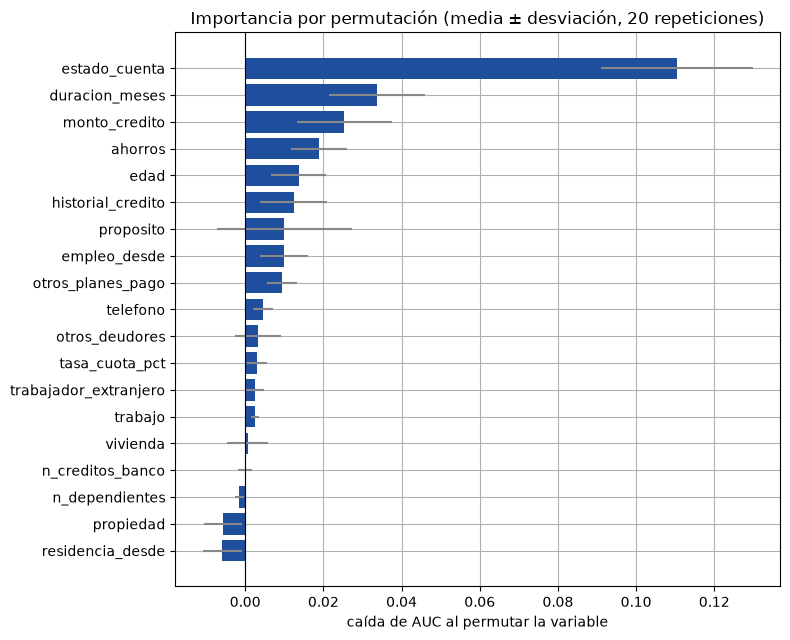

In [3]:
# Figura · importancia por permutación (con desviación entre repeticiones)
from sklearn.inspection import permutation_importance
pi = permutation_importance(model, X_te, y_te, scoring="roc_auc",
                            n_repeats=20, random_state=RANDOM_STATE)
orden = np.argsort(pi.importances_mean)
plt.figure(figsize=(8, 6.5))
plt.barh(np.array(Xraw.columns)[orden], pi.importances_mean[orden],
         xerr=pi.importances_std[orden], color="#1f4e9c", ecolor="#888")
plt.axvline(0, color="k", lw=.8)
plt.xlabel("caída de AUC al permutar la variable")
plt.title("Importancia por permutación (media ± desviación, 20 repeticiones)")
plt.tight_layout(); plt.show()

**Precaución bajo correlación.** Si dos variables están correlacionadas, permutar una sola subestima su importancia (el modelo recupera la información vía la otra) y, además, genera combinaciones poco realistas que extrapolan fuera del soporte de los datos. Esta es la misma debilidad que afecta a los gráficos de dependencia parcial de la sección siguiente, y que ALE corrige.

## Sección 2 · Dependencia parcial (PDP) e individual (ICE)

El **PDP** (Friedman, 2001) muestra el efecto marginal *promedio* de una variable sobre la predicción, marginalizando las demás:

$$ \hat f_S(x_S) \;=\; \mathbb E_{X_C}\big[\hat f(x_S, X_C)\big] \;\approx\; \frac{1}{n}\sum_{i=1}^{n} \hat f\big(x_S, x_C^{(i)}\big). $$

Las curvas **ICE** (Goldstein et al., 2015) son lo mismo *sin promediar*: una línea por observación. Revelan heterogeneidad e interacciones que el promedio del PDP oculta. El supuesto implícito —independencia entre $X_S$ y $X_C$— hace que el PDP evalúe el modelo en combinaciones $(x_S, x_C)$ posiblemente irreales cuando hay correlación.

> **Definición 2.1 (dependencia parcial, PDP).** $\displaystyle \hat f_S(x_S)=\mathbb E_{X_C}\big[\hat f(x_S,X_C)\big]\approx\frac1n\sum_{i=1}^n \hat f\big(x_S,x_C^{(i)}\big)$, integrando $X_C$ contra su distribución **marginal**.
>
> **Definición 2.2 (expectativa condicional individual, ICE).** La curva ICE de la observación $i$ es $x_S\mapsto \hat f(x_S,x_C^{(i)})$: un PDP sin promediar. El PDP es el promedio de las curvas ICE.
>
> **Proposición 2.1 (el PDP es una esperanza intervencional).** Si $X_C$ no son descendientes de $X_S$, el PDP coincide con la esperanza bajo intervención:
> $$ \hat f_S(x_S)=\mathbb E\big[\hat f\mid do(X_S=x_S)\big]. $$
>
> **Demostración.** El PDP integra $\hat f(x_S,x_C)$ contra la marginal $p(x_C)$. Por la *factorización truncada* del operador $do$, cuando $X_C$ no desciende de $X_S$ se tiene $p(x_C\mid do(x_S))=p(x_C)$; luego $\mathbb E[\hat f\mid do(X_S=x_S)]=\int \hat f(x_S,x_C)\,p(x_C)\,dx_C=\hat f_S(x_S)$. $\blacksquare$
>
> **Observación 2.1.** Por ello el PDP hereda la debilidad del SHAP **intervencional** bajo correlación (cuaderno 04): evalúa $\hat f$ en combinaciones $(x_S,x_C)$ posiblemente irreales. ALE lo corrige usando diferencias **locales**.

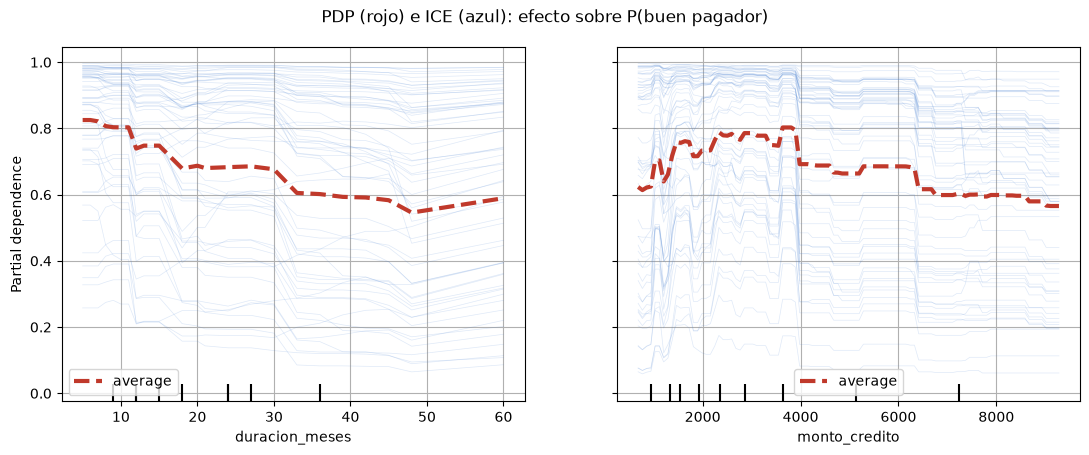

In [4]:
# Figura · PDP (promedio) + ICE (individuales) para dos variables numéricas
from sklearn.inspection import PartialDependenceDisplay
disp = PartialDependenceDisplay.from_estimator(
    model, X_te, ["duracion_meses", "monto_credito"], kind="both",
    subsample=60, random_state=RANDOM_STATE,
    ice_lines_kw={"alpha": 0.18, "color": "#4f86d6"},
    pd_line_kw={"color": "#c0392b", "lw": 3})
disp.figure_.set_size_inches(11, 4.6)
disp.figure_.suptitle("PDP (rojo) e ICE (azul): efecto sobre P(buen pagador)")
plt.tight_layout(); plt.show()

## Sección 3 · Efectos locales acumulados (ALE)

ALE (Apley & Zhu, 2020) corrige el sesgo del PDP usando **diferencias locales dentro de intervalos** y acumulándolas, en vez de marginalizar sobre la distribución completa. Para la variable $j$, con bordes de intervalo $z_0<\dots<z_K$ (cuantiles), el efecto no centrado es

$$ \widehat{\text{ALE}}(z_k) \;=\; \sum_{m=1}^{k} \frac{1}{n_m}\!\!\sum_{i:\,x^{(i)}_j\in(z_{m-1},z_m]}\!\!\big[\hat f(z_m, x^{(i)}_{\setminus j}) - \hat f(z_{m-1}, x^{(i)}_{\setminus j})\big], $$

y luego se **centra** restando su media ponderada por frecuencia. Como solo evalúa el modelo en combinaciones realmente observadas en cada intervalo, **no extrapola** y es insesgado bajo correlación. Se implementa a continuación y se compara con el PDP.

> **Definición 3.1 (efectos locales acumulados, ALE).** Con bordes de intervalo $z_0<\dots<z_K$ (cuantiles de $X_j$), el ALE no centrado es
> $$ \widehat{\mathrm{ALE}}(z_k)=\sum_{m=1}^{k}\frac1{n_m}\!\!\sum_{i:\,x^{(i)}_j\in(z_{m-1},z_m]}\!\!\big[\hat f(z_m,x^{(i)}_{\setminus j})-\hat f(z_{m-1},x^{(i)}_{\setminus j})\big], $$
> y se centra restando su media ponderada por frecuencia. Solo evalúa $\hat f$ en combinaciones observadas dentro de cada intervalo, por lo que **no extrapola** y es insesgado bajo correlación.

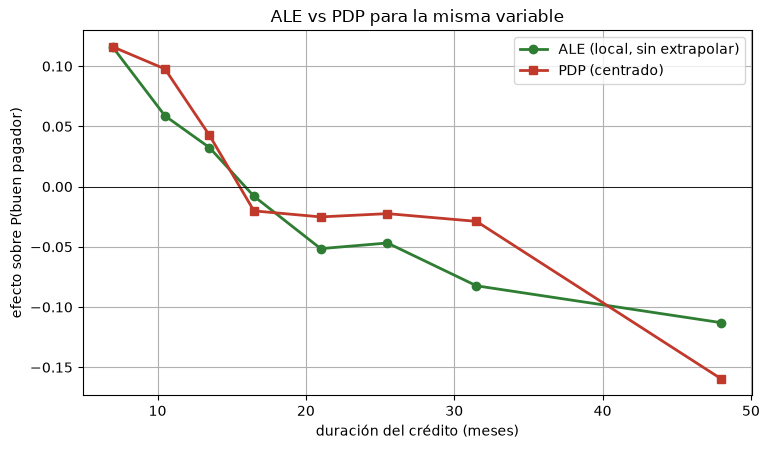

In [5]:
# ALE 1D (implementación directa) y comparación con PDP
def ale_1d(modelo, X, feat, n_bins=10):
    x = X[feat].to_numpy()
    edges = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    K = len(edges) - 1
    b = np.clip(np.searchsorted(edges, x, side="left"), 1, K)
    delta = np.zeros(K); counts = np.zeros(K)
    for k in range(1, K + 1):
        m = b == k
        counts[k - 1] = m.sum()
        if m.sum() == 0:
            continue
        Xl = X[m].copy(); Xu = X[m].copy()
        Xl[feat] = edges[k - 1]; Xu[feat] = edges[k]
        delta[k - 1] = (modelo.predict_proba(Xu)[:, 1] - modelo.predict_proba(Xl)[:, 1]).mean()
    acc = np.concatenate([[0.0], np.cumsum(delta)])
    mid = (acc[1:] + acc[:-1]) / 2
    acc -= np.sum(counts * mid) / counts.sum()          # centrado
    return edges, acc

def pdp_1d(modelo, X, feat, grid):
    out = []
    for v in grid:
        Xt = X.copy(); Xt[feat] = v
        out.append(modelo.predict_proba(Xt)[:, 1].mean())
    return np.array(out)

feat = "duracion_meses"
edges, ale = ale_1d(model, X_te, feat, n_bins=10)
grid = (edges[:-1] + edges[1:]) / 2
ale_mid = (ale[:-1] + ale[1:]) / 2
pdp = pdp_1d(model, X_te, feat, grid); pdp = pdp - pdp.mean()

plt.figure(figsize=(7.8, 4.6))
plt.plot(grid, ale_mid, "-o", color="#2e7d32", lw=2, label="ALE (local, sin extrapolar)")
plt.plot(grid, pdp, "-s", color="#c0392b", lw=2, label="PDP (centrado)")
plt.axhline(0, color="k", lw=.6)
plt.xlabel("duración del crédito (meses)"); plt.ylabel("efecto sobre P(buen pagador)")
plt.title("ALE vs PDP para la misma variable")
plt.legend(); plt.tight_layout(); plt.show()

Ambas curvas describen el mismo efecto descendente (créditos más largos → menor probabilidad de buen pagador), pero el ALE lo estima sin evaluar el modelo en combinaciones irreales. Cuando la variable está fuertemente correlacionada con otras, las dos curvas pueden divergir de forma apreciable; en ese caso, **ALE es la lectura confiable**.

## Sección 4 · Modelo sustituto global

Un **modelo sustituto** es un modelo interpretable $g$ entrenado para **reproducir las predicciones** de la caja negra $f$ (no las etiquetas reales). Se ajusta $g$ sobre $(X, f(X))$ y se mide su **fidelidad** —cuán bien imita a $f$— con $R^2$:

$$ R^2 = 1 - \frac{\sum_i \big(f(x_i) - g(x_i)\big)^2}{\sum_i \big(f(x_i) - \bar f\big)^2}. $$

Una fidelidad alta justifica leer $g$ como aproximación global de $f$; una baja advierte que el resumen es parcial. Usamos un árbol de decisión de profundidad 3, legible de un vistazo.

> **Definición 4.1 (modelo sustituto global).** Un *sustituto global* es un modelo interpretable $g$ ajustado para reproducir las predicciones de la caja negra $f$ —es decir, sobre los pares $(x_i, f(x_i))$, no sobre las etiquetas reales—.
>
> **Definición 4.2 (fidelidad).** La *fidelidad* de $g$ es su bondad de ajuste a $f$,
> $$ R^2=1-\frac{\sum_i \big(f(x_i)-g(x_i)\big)^2}{\sum_i \big(f(x_i)-\bar f\big)^2}. $$
> Una fidelidad alta justifica leer $g$ como resumen **global** de $f$; una baja advierte que el resumen es parcial.

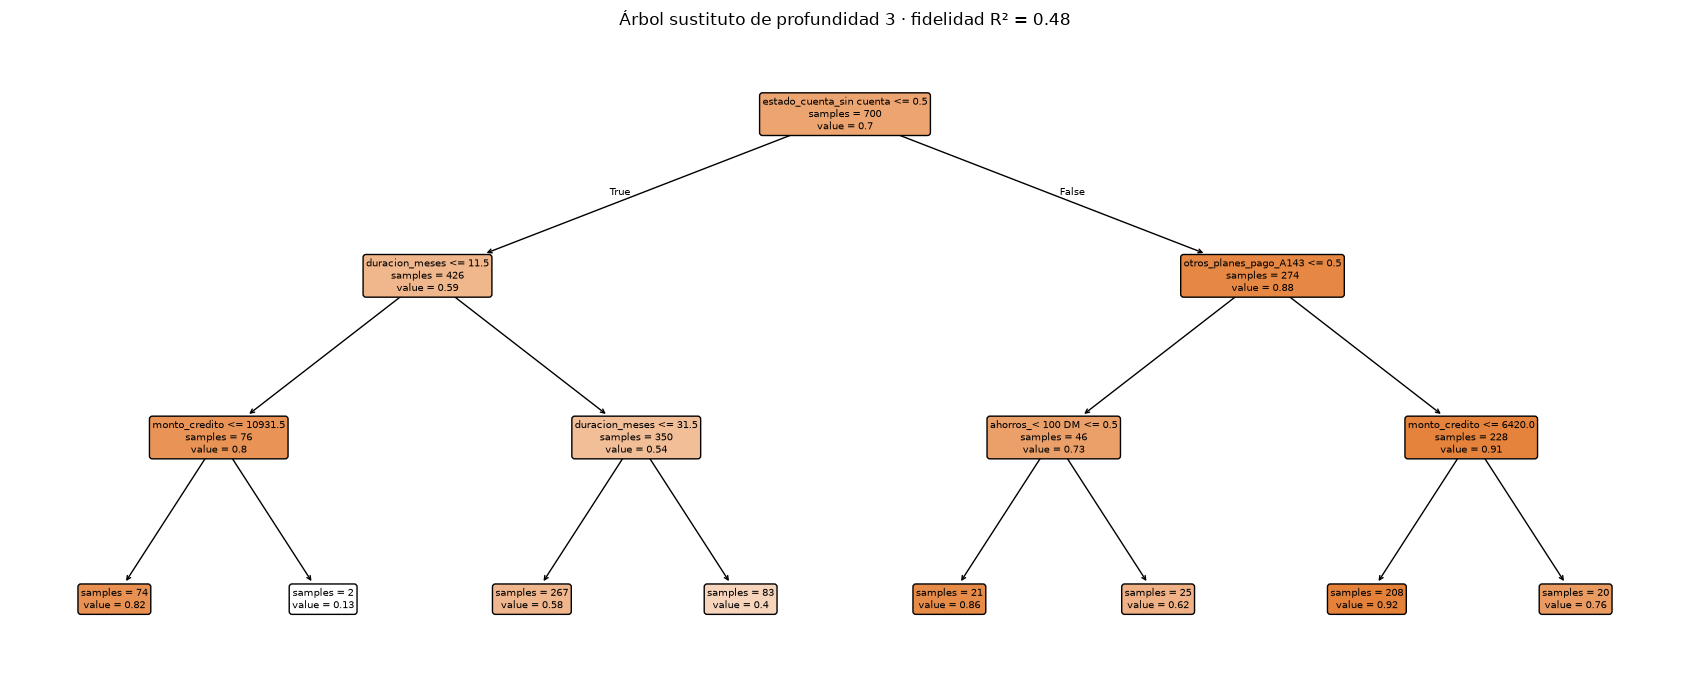

Fidelidad del sustituto (R² sobre prueba): 0.476


In [6]:
# Árbol sustituto que imita la probabilidad de la caja negra + fidelidad R²
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score

nombres = model.named_steps["pre"].get_feature_names_out()
Xtr_enc = model.named_steps["pre"].transform(X_tr)
Xte_enc = model.named_steps["pre"].transform(X_te)
p_tr = model.predict_proba(X_tr)[:, 1]
p_te = model.predict_proba(X_te)[:, 1]

sur = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE).fit(Xtr_enc, p_tr)
fid = r2_score(p_te, sur.predict(Xte_enc))

plt.figure(figsize=(17, 7))
plot_tree(sur, feature_names=list(nombres), filled=True, fontsize=7, precision=2,
          impurity=False, rounded=True)
plt.title(f"Árbol sustituto de profundidad 3 · fidelidad R² = {fid:.2f}")
plt.tight_layout(); plt.show()
print(f"Fidelidad del sustituto (R² sobre prueba): {fid:.3f}")

La fidelidad cuantifica el compromiso **interpretabilidad ↔ exactitud**: un árbol corto es legible pero solo captura la estructura gruesa del modelo; profundizarlo aumenta la fidelidad a costa de la legibilidad. El sustituto es, además, una aproximación **global** —no garantiza fidelidad en casos individuales—, para lo cual sirven las explicaciones locales del cuaderno 02.

## Sección 5 · Explicaciones contrafactuales (DiCE)

Una explicación contrafactual responde: *¿cuál es el cambio mínimo en $x$ que voltea la decisión del modelo?* Es la base del **recurso algorítmico** (qué debería cambiar un solicitante rechazado para ser aprobado). Se formula como una optimización (Wachter et al., 2017):

$$ x_{cf} \;=\; \arg\min_{x'}\; \underbrace{\text{yloss}\big(f(x'), y^{*}\big)}_{\text{alcanzar la clase deseada}} \;+\; \lambda\, \underbrace{d(x, x')}_{\text{proximidad / dispersión}}, $$

donde $y^*$ es la clase objetivo y $d$ penaliza cambios grandes o numerosos (favoreciendo contrafactuales *próximos* y *dispersos*). **DiCE** (Mothilal et al., 2020) añade **diversidad** para ofrecer varias alternativas. Se generan contrafactuales para un solicitante rechazado.

In [7]:
# Contrafactuales con DiCE para un solicitante RECHAZADO
import dice_ml

train_df = X_tr.copy(); train_df["riesgo_bueno"] = y_tr.values
d_data = dice_ml.Data(dataframe=train_df, continuous_features=num, outcome_name="riesgo_bueno")
d_model = dice_ml.Model(model=model, backend="sklearn")
dice = dice_ml.Dice(d_data, d_model, method="random")

pred_te = model.predict(X_te)
j = int(np.where(pred_te == 0)[0][0])          # primer caso clasificado como 'mal pagador'
query = X_te.iloc[[j]]
accionables = ["duracion_meses", "monto_credito", "tasa_cuota_pct",
               "ahorros", "estado_cuenta", "empleo_desde", "otros_planes_pago"]
cf = dice.generate_counterfactuals(query, total_CFs=3, desired_class="opposite",
                                   features_to_vary=accionables)
cf_df = cf.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
orig = query.iloc[0]

print(f"Solicitante #{j} clasificado como MAL pagador. Contrafactuales hacia 'buen pagador':\n")
for i, row in cf_df.drop(columns=["riesgo_bueno"]).iterrows():
    camb = {c: (orig[c], row[c]) for c in Xraw.columns if str(orig[c]) != str(row[c])}
    print(f"CF{i+1}:  " + "   |   ".join(f"{c}: {a} → {b}" for c, (a, b) in camb.items()))

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 11.31it/s]

Solicitante #1 clasificado como MAL pagador. Contrafactuales hacia 'buen pagador':

CF1:  estado_cuenta: < 0 DM → sin cuenta   |   tasa_cuota_pct: 4.0 → 1.8
CF2:  monto_credito: 339.0 → 8102.6   |   empleo_desde: >= 7 años → < 1 año
CF3:  estado_cuenta: < 0 DM → 0-200 DM   |   ahorros: < 100 DM → desconocido/sin ahorros


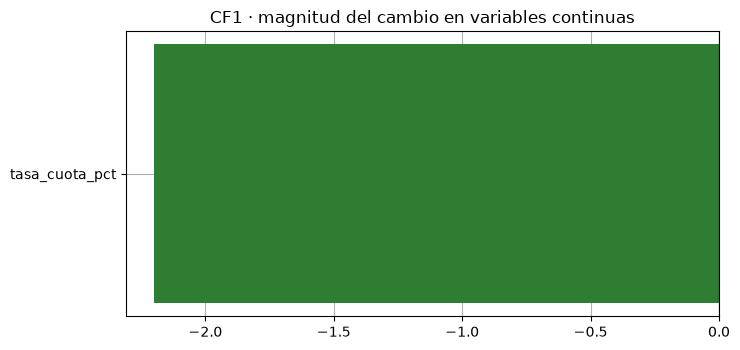

In [8]:
# Figura · cambios del primer contrafactual en las variables continuas
cf1 = cf_df.drop(columns=["riesgo_bueno"]).iloc[0]
deltas = {c: float(cf1[c]) - float(orig[c]) for c in num if str(orig[c]) != str(cf1[c])}
if deltas:
    plt.figure(figsize=(7.5, 3.6))
    plt.barh(list(deltas), list(deltas.values()),
             color=["#2e7d32" if v < 0 else "#c0392b" for v in deltas.values()])
    plt.axvline(0, color="k", lw=.8)
    plt.title("CF1 · magnitud del cambio en variables continuas")
    plt.tight_layout(); plt.show()
else:
    print("El primer contrafactual solo modifica variables categóricas.")

**Advertencia causal.** Estos contrafactuales son del **modelo**, no del mundo: indican cómo cambiar las *entradas* para mover la *predicción*, pero pueden proponer combinaciones poco plausibles o no accionables si ignoran las relaciones causales entre variables (p. ej., modificar el monto sin alterar la cuota). Un contrafactual *causalmente* válido exige respetar el mecanismo generador —el operador $do(\cdot)$ y los modelos estructurales de la Sección 2 del curso—. Es la transición hacia el cuaderno 04.

## Síntesis

- **Permutación**: importancia global por caída de desempeño; sensible a la correlación.
- **PDP/ICE**: efecto marginal promedio (PDP) e individual (ICE); el PDP se sesga al extrapolar bajo correlación.
- **ALE**: corrige ese sesgo con diferencias locales acumuladas; lectura confiable con variables correlacionadas.
- **Sustituto global**: árbol interpretable que imita a $f$, con fidelidad cuantificable.
- **Contrafactuales (DiCE)**: recurso accionable a nivel de un caso; del modelo, no causal.

**Límite común.** Todos describen el modelo sobre la **distribución observada**; ninguno responde qué ocurriría bajo una **intervención**. El cuaderno 04 muestra dónde y por qué falla esto en SHAP (el problema del *proxy* visto en el 02) y cómo lo corrige el SHAP causal (*do-SHAP*), abriendo la Sección 2 del curso.

## Ejemplos complementarios

Tres ejemplos desarrollados que reutilizan las funciones y el modelo de las secciones anteriores.

### Ejemplo 1 · PDP frente a ALE para el monto del crédito

Se repite la comparación de la Sección 3 sobre `monto_credito`, una variable correlacionada con la duración; es donde más puede divergir el PDP del ALE.

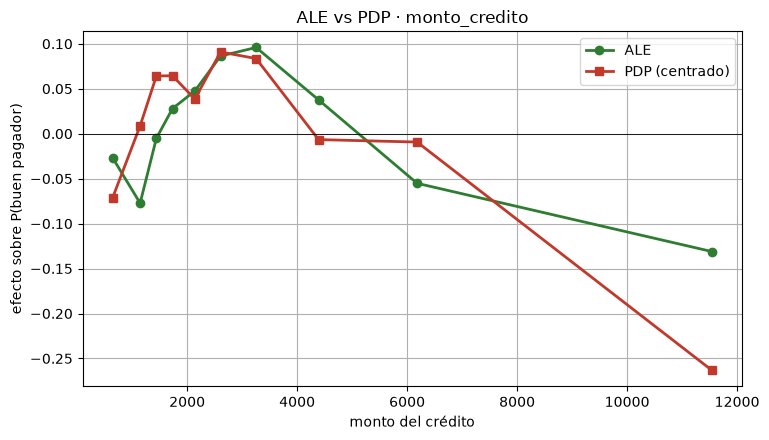

In [9]:
feat2 = "monto_credito"
edges2, ale2 = ale_1d(model, X_te, feat2, n_bins=10)
grid2 = (edges2[:-1] + edges2[1:]) / 2
ale2_mid = (ale2[:-1] + ale2[1:]) / 2
pdp2 = pdp_1d(model, X_te, feat2, grid2); pdp2 = pdp2 - pdp2.mean()
plt.figure(figsize=(7.8, 4.5))
plt.plot(grid2, ale2_mid, "-o", color="#2e7d32", lw=2, label="ALE")
plt.plot(grid2, pdp2, "-s", color="#c0392b", lw=2, label="PDP (centrado)")
plt.axhline(0, color="k", lw=.6)
plt.xlabel("monto del crédito"); plt.ylabel("efecto sobre P(buen pagador)")
plt.title("ALE vs PDP · monto_credito"); plt.legend(); plt.tight_layout(); plt.show()

### Ejemplo 2 · Fidelidad del modelo sustituto según su profundidad

Se entrena el árbol sustituto a profundidades crecientes y se mide su fidelidad $R^2$ frente a la caja negra: el compromiso interpretabilidad ↔ exactitud, cuantificado.

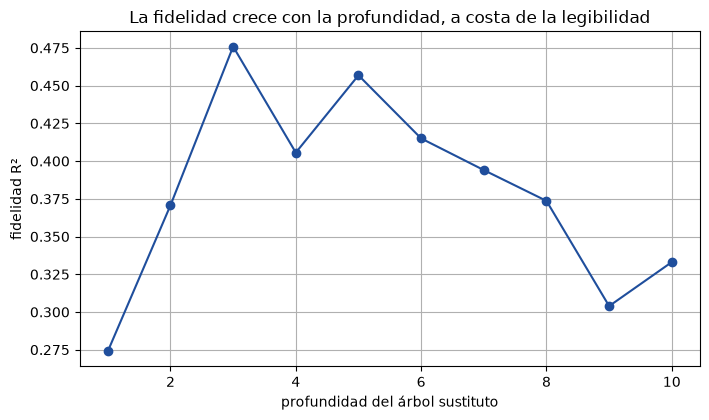

R² por profundidad: [0.27, 0.37, 0.48, 0.41, 0.46, 0.42, 0.39, 0.37, 0.3, 0.33]


In [10]:
profundidades = range(1, 11); fids = []
for dprof in profundidades:
    s = DecisionTreeRegressor(max_depth=dprof, random_state=RANDOM_STATE).fit(Xtr_enc, p_tr)
    fids.append(r2_score(p_te, s.predict(Xte_enc)))
plt.figure(figsize=(7.2, 4.3))
plt.plot(list(profundidades), fids, "-o", color="#1f4e9c")
plt.xlabel("profundidad del árbol sustituto"); plt.ylabel("fidelidad R²")
plt.title("La fidelidad crece con la profundidad, a costa de la legibilidad")
plt.tight_layout(); plt.show()
print("R² por profundidad:", [round(f, 2) for f in fids])

### Ejemplo 3 · Correlación entre variables e importancia por permutación

Se mide la correlación entre el monto y la duración del crédito, y se contrastan sus importancias por permutación, ilustrando la precaución señalada en la Sección 1.

In [11]:
r_md = X_te["monto_credito"].corr(X_te["duracion_meses"])
print(f"corr(monto, duración) = {r_md:+.3f}")
for c in ["monto_credito", "duracion_meses"]:
    pos = list(Xraw.columns).index(c)
    print(f"  importancia por permutación de {c:16s}: {pi.importances_mean[pos]:+.4f}")
print("\nAl estar correlacionadas, permutar una sola subestima su importancia "
      "(el modelo recupera parte de la información vía la otra).")

corr(monto, duración) = +0.639
  importancia por permutación de monto_credito   : +0.0254
  importancia por permutación de duracion_meses  : +0.0336

Al estar correlacionadas, permutar una sola subestima su importancia (el modelo recupera parte de la información vía la otra).


### Ejemplo 4 · Contrafactuales restringidos a variables accionables

Se regeneran los contrafactuales permitiendo variar **solo** un conjunto de variables que el solicitante podría modificar de forma realista.

In [12]:
accionables2 = ["duracion_meses", "monto_credito", "ahorros"]
cf2 = dice.generate_counterfactuals(query, total_CFs=3, desired_class="opposite",
                                    features_to_vary=accionables2)
cf2_df = cf2.cf_examples_list[0].final_cfs_df.reset_index(drop=True)
print(f"Contrafactuales variando solo {accionables2}:\n")
for i, row in cf2_df.drop(columns=["riesgo_bueno"]).iterrows():
    camb = {c: (orig[c], row[c]) for c in Xraw.columns if str(orig[c]) != str(row[c])}
    print(f"CF{i+1}:  " + "   |   ".join(f"{c}: {a} → {b}" for c, (a, b) in camb.items()))

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 11.19it/s]

Contrafactuales variando solo ['duracion_meses', 'monto_credito', 'ahorros']:

CF1:  duracion_meses: 12.0 → 30.8   |   ahorros: < 100 DM → >= 1000 DM
CF2:  monto_credito: 339.0 → 7560.7
CF3:  monto_credito: 339.0 → 1940.5


### Ejemplo 5 · Plausibilidad de los contrafactuales

Un contrafactual lejano a los datos reales es poco plausible. Se mide la distancia (en variables continuas estandarizadas) de cada contrafactual al ejemplo de entrenamiento más cercano, y se compara con la del caso original.

In [13]:
from scipy.spatial.distance import cdist
mu, sd = X_tr[num].mean(), X_tr[num].std()
ref_pts = ((X_tr[num] - mu) / sd).to_numpy()
def plausibilidad(row):
    v = ((row[num].astype(float) - mu) / sd).to_numpy().reshape(1, -1)
    return float(cdist(v, ref_pts).min())

d_orig = plausibilidad(orig)
print(f"distancia del caso ORIGINAL a su vecino real más cercano: {d_orig:.2f}\n")
for i, row in cf_df.drop(columns=["riesgo_bueno"]).iterrows():
    d = plausibilidad(row)
    print(f"  CF{i+1}: distancia = {d:.2f}   ->  {'plausible' if d <= d_orig + 1.0 else 'atípico (poco plausible)'}")

distancia del caso ORIGINAL a su vecino real más cercano: 0.60

  CF1: distancia = 0.63   ->  plausible
  CF2: distancia = 1.84   ->  atípico (poco plausible)
  CF3: distancia = 0.60   ->  plausible


## Referencias (APA 7)

- Apley, D. W., & Zhu, J. (2020). Visualizing the effects of predictor variables in black box supervised learning models. *Journal of the Royal Statistical Society: Series B, 82*(4), 1059–1086.
- Breiman, L. (2001). Random forests. *Machine Learning, 45*(1), 5–32.
- Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. *Annals of Statistics, 29*(5), 1189–1232.
- Goldstein, A., Kapelner, A., Bleich, J., & Pitkin, E. (2015). Peeking inside the black box: Visualizing statistical learning with plots of individual conditional expectation. *Journal of Computational and Graphical Statistics, 24*(1), 44–65.
- Molnar, C. (2022). *Interpretable machine learning: A guide for making black box models explainable* (2nd ed.).
- Mothilal, R. K., Sharma, A., & Tan, C. (2020). Explaining machine learning classifiers through diverse counterfactual explanations. *FAT* '20*, 607–617.
- Verma, S., Dickerson, J., & Hines, K. (2021). *Counterfactual explanations for machine learning: Challenges revisited* [Preprint]. arXiv:2106.07756.
- Wachter, S., Mittelstadt, B., & Russell, C. (2017). Counterfactual explanations without opening the black box: Automated decisions and the GDPR. *Harvard Journal of Law & Technology, 31*(2), 841–887.